In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
dataset = load_dataset("imdb")

texts = dataset["train"]["text"][:5000]   # small subset for demo
labels = dataset["train"]["label"][:5000]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [3]:
vectorizer = TfidfVectorizer(max_features=2000)

X = vectorizer.fit_transform(texts).toarray()
y = labels


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


In [5]:
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()

        self.fc1 = nn.Linear(2000, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 2)   # Positive / Negative

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x


In [6]:
model = FeedForwardNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [7]:
num_epochs = 10

for epoch in range(num_epochs):

    outputs = model(X_train)              # forward pass
    loss = criterion(outputs, y_train)    # compute loss

    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # BACKPROPAGATION
    optimizer.step()        # update weights

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/10], Loss: 0.7075
Epoch [2/10], Loss: 0.6898
Epoch [3/10], Loss: 0.6717
Epoch [4/10], Loss: 0.6512
Epoch [5/10], Loss: 0.6287
Epoch [6/10], Loss: 0.6058
Epoch [7/10], Loss: 0.5819
Epoch [8/10], Loss: 0.5550
Epoch [9/10], Loss: 0.5243
Epoch [10/10], Loss: 0.4901


In [8]:
with torch.no_grad():
    test_outputs = model(X_test)
    _, predictions = torch.max(test_outputs, 1)

accuracy = accuracy_score(y_test, predictions)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Test Accuracy: 100.00%


In [11]:
new_text = ["This movie was good and full of fun"]

vec = vectorizer.transform(new_text).toarray()
vec = torch.tensor(vec, dtype=torch.float32)

with torch.no_grad():
    output = model(vec)
    pred = torch.argmax(output, dim=1)

print("Prediction:", "Positive" if pred.item() == 1 else "Negative")


Prediction: Negative


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import re
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter


In [14]:
# ===============================
# 2. Load Dataset (IMDB - open source)
# ===============================
dataset = load_dataset("imdb")

texts = dataset["train"]["text"][:20000]
labels = dataset["train"]["label"][:20000]

# ===============================
# 3. Text Cleaning
# ===============================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)          # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)      # remove punctuation & numbers
    return text

texts = [clean_text(t) for t in texts]

print("Class distribution:", Counter(labels))

# ===============================
# 4. TF-IDF Vectorization
# ===============================
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)   # unigrams + bigrams
)

X = vectorizer.fit_transform(texts).toarray()
y = labels

# ===============================
# 5. Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# ===============================
# 6. Define Feed Forward Neural Network
# ===============================
class FeedForwardNN(nn.Module):
    def __init__(self):
        super(FeedForwardNN, self).__init__()

        self.fc1 = nn.Linear(5000, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 2)  # positive / negative

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

model = FeedForwardNN()

# ===============================
# 7. Loss and Optimizer
# ===============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ===============================
# 8. Training (Backpropagation)
# ===============================
num_epochs = 15

for epoch in range(num_epochs):

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()        # BACKPROPAGATION
    optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

# ===============================
# 9. Evaluation
# ===============================
with torch.no_grad():
    test_outputs = model(X_test)
    _, predictions = torch.max(test_outputs, 1)

accuracy = accuracy_score(y_test, predictions)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# ===============================
# 10. Prediction on New Text
# ===============================
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text]).toarray()
    vec = torch.tensor(vec, dtype=torch.float32)

    with torch.no_grad():
        output = model(vec)
        pred = torch.argmax(output, dim=1)

    return "Positive" if pred.item() == 1 else "Negative"


# Test sentences
samples = [
    "This movie was fantastic and full of emotions",
    "I hated this movie and it was boring",
    "The acting was great and story was amazing",
    "Worst film I have ever seen"
]

for s in samples:
    print(f"{s} → {predict_sentiment(s)}")

Class distribution: Counter({0: 12500, 1: 7500})
Epoch [1/15], Loss: 0.6867
Epoch [2/15], Loss: 0.6826
Epoch [3/15], Loss: 0.6780
Epoch [4/15], Loss: 0.6727
Epoch [5/15], Loss: 0.6670
Epoch [6/15], Loss: 0.6609
Epoch [7/15], Loss: 0.6542
Epoch [8/15], Loss: 0.6466
Epoch [9/15], Loss: 0.6379
Epoch [10/15], Loss: 0.6280
Epoch [11/15], Loss: 0.6168
Epoch [12/15], Loss: 0.6043
Epoch [13/15], Loss: 0.5907
Epoch [14/15], Loss: 0.5760
Epoch [15/15], Loss: 0.5603

Test Accuracy: 69.10%
This movie was fantastic and full of emotions → Negative
I hated this movie and it was boring → Negative
The acting was great and story was amazing → Negative
Worst film I have ever seen → Negative


In [15]:
# pip install torch scikit-learn datasets

import torch
import torch.nn as nn
import torch.optim as optim
import re
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
from collections import Counter

# =====================
# Load dataset
# =====================
dataset = load_dataset("imdb")

texts = dataset["train"]["text"]
labels = dataset["train"]["label"]

# balance dataset
texts = texts[:25000]
labels = labels[:25000]

print("Class distribution:", Counter(labels))

# =====================
# Text cleaning
# =====================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

texts = [clean_text(t) for t in texts]

# =====================
# TF-IDF
# =====================
vectorizer = TfidfVectorizer(
    max_features=8000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=5
)

X = vectorizer.fit_transform(texts).toarray()
y = labels

# =====================
# Train/Test split
# =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# =====================
# FFN model
# =====================
class FeedForwardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8000, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

model = FeedForwardNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# =====================
# Training (mini-batch + backprop)
# =====================
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

# =====================
# Evaluation
# =====================
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

accuracy = accuracy_score(y_test, preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

# =====================
# Prediction function
# =====================
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text]).toarray()
    vec = torch.tensor(vec, dtype=torch.float32)

    with torch.no_grad():
        output = model(vec)
        pred = torch.argmax(output, dim=1)

    return "Positive" if pred.item() == 1 else "Negative"

# =====================
# Test samples
# =====================
samples = [
    "This movie was fantastic and full of emotions",
    "I hated this movie and it was boring",
    "The acting was great and story was amazing",
    "Worst film I have ever seen"
]

for s in samples:
    print(s, "→", predict_sentiment(s))


Class distribution: Counter({0: 12500, 1: 12500})
Epoch [1/15], Loss: 0.3721
Epoch [2/15], Loss: 0.1949
Epoch [3/15], Loss: 0.1266
Epoch [4/15], Loss: 0.0699
Epoch [5/15], Loss: 0.0317
Epoch [6/15], Loss: 0.0147
Epoch [7/15], Loss: 0.0075
Epoch [8/15], Loss: 0.0062
Epoch [9/15], Loss: 0.0049
Epoch [10/15], Loss: 0.0029
Epoch [11/15], Loss: 0.0036
Epoch [12/15], Loss: 0.0027
Epoch [13/15], Loss: 0.0044
Epoch [14/15], Loss: 0.0040
Epoch [15/15], Loss: 0.0032

Test Accuracy: 87.00%
This movie was fantastic and full of emotions → Positive
I hated this movie and it was boring → Negative
The acting was great and story was amazing → Positive
Worst film I have ever seen → Negative


In [ ]:
loss_history = []


In [16]:
loss_history = []

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")


Epoch [1/15], Loss: 0.0041
Epoch [2/15], Loss: 0.0029
Epoch [3/15], Loss: 0.0036
Epoch [4/15], Loss: 0.0031
Epoch [5/15], Loss: 0.0023
Epoch [6/15], Loss: 0.0035
Epoch [7/15], Loss: 0.0015
Epoch [8/15], Loss: 0.0025
Epoch [9/15], Loss: 0.0017
Epoch [10/15], Loss: 0.0020
Epoch [11/15], Loss: 0.0020
Epoch [12/15], Loss: 0.0018
Epoch [13/15], Loss: 0.0011
Epoch [14/15], Loss: 0.0007
Epoch [15/15], Loss: 0.0011


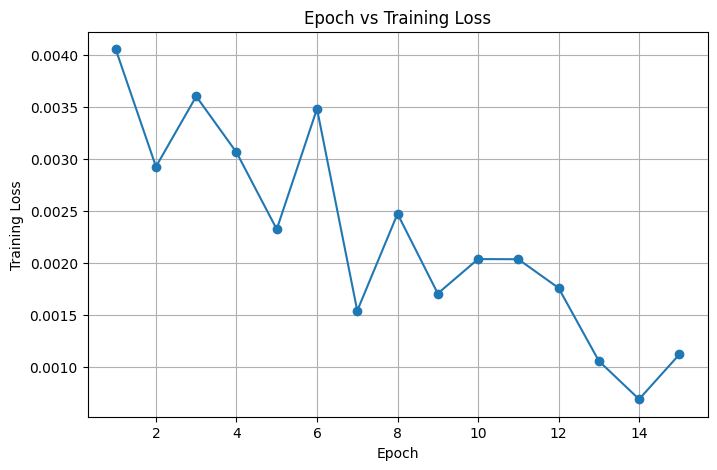

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(loss_history)+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Epoch vs Training Loss")
plt.grid(True)
plt.show()
